In [1]:
from load_results import load_result_dataset
import pandas as pd
import numpy as np
pn1 = 'full_fine_tuning_50epochs_edge_paper_final2'
pn2 = 'full_fine_tuning_50epochs_paper_final2'
pn3 = 'none' #'full_fine_tuning_50epochs_budget'

final_data = load_result_dataset(pn1, pn2, pn3)
final_data = [{**d, 'ft_strategy': 'FFT (50 epochs)'} for d in final_data]

../results/none/CLIP-convnext_base_w-laion_aesthetic-s13B-b82K_uc-merced-land-use-dataset_TRADES_v2.pkl
HEY
../results/full_fine_tuning_50epochs_paper_final2/CLIP-convnext_base_w-laion_aesthetic-s13B-b82K_uc-merced-land-use-dataset_TRADES_v2.pkl
../results/none/CLIP-convnext_base_w-laion2B-s13B-b82K_uc-merced-land-use-dataset_TRADES_v2.pkl
HEY
../results/full_fine_tuning_50epochs_paper_final2/CLIP-convnext_base_w-laion2B-s13B-b82K_uc-merced-land-use-dataset_TRADES_v2.pkl
../results/none/deit_small_patch16_224.fb_in1k_uc-merced-land-use-dataset_TRADES_v2.pkl
HEY
../results/full_fine_tuning_50epochs_paper_final2/deit_small_patch16_224.fb_in1k_uc-merced-land-use-dataset_TRADES_v2.pkl
../results/none/robust_resnet50_uc-merced-land-use-dataset_TRADES_v2.pkl
HEY
../results/full_fine_tuning_50epochs_paper_final2/robust_resnet50_uc-merced-land-use-dataset_TRADES_v2.pkl
../results/none/vit_small_patch16_224.augreg_in21k_uc-merced-land-use-dataset_TRADES_v2.pkl
HEY
../results/full_fine_tuning_50

In [2]:
from process_database import process_grouped_df, process_rankings, compute_odds_ratio_by_group

grouped_df = process_grouped_df(final_data,   )
grouped_df = process_rankings(grouped_df)
grouped_df = grouped_df[ ('TOTAL', )].reset_index()
grouped_df

Percentage of NaN values: 0.00%


metric,backbone,backbone_name,loss_function,pre_training_strategy,model_type,model_size,ft_strategy,borda,nan_geom_cnt,nan_sum_cnt,rank_borda,rank_geom,rank_sum,score_geom,score_sum
0,convnext_base.fb_in22k,"convnext_b,sup,in22k",TRADES,supervised,fully convolutional,Base,FFT (50 epochs),2281.0,0,0,1.0,1.0,1.0,1.320645,19.789302
1,coatnet_2_rw_224.sw_in12k_ft_in1k,"coatnet_2,sup,in12k-in1k",TRADES,supervised (multistep),hybrid,Base,FFT (50 epochs),2127.0,0,0,2.0,2.0,4.0,1.147118,18.743905
2,coatnet_2_rw_224.sw_in12k,"coatnet_2,sup,in12k",TRADES,supervised,hybrid,Base,FFT (50 epochs),2116.0,0,0,3.0,3.0,3.0,1.085487,18.874429
3,CLIP-convnext_base_w-laion2B-s13B-b82K,"convnext_b,clip,laion2b",TRADES,self-supervised (multimodal),fully convolutional,Base,FFT (50 epochs),2067.0,0,0,4.0,6.0,2.0,1.001878,19.396968
4,convnext_base.fb_in22k_ft_in1k,"convnext_b,sup,in22k-in1k",TRADES,supervised (multistep),fully convolutional,Base,FFT (50 epochs),2001.0,0,0,5.0,12.0,8.0,0.815672,17.016397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,mobilevit-small,"mobilevit_s,sup,in1k",TRADES,supervised,hybrid,Tiny,FFT (50 epochs),554.0,0,0,76.0,76.0,74.0,0.022693,5.632667
76,vit_small_patch16_224.augreg_in1k,"vit_s,sup,in1k",Classic AT,supervised,fully attention,Small,FFT (50 epochs),433.0,0,0,77.0,80.0,80.0,0.000950,2.742905
77,efficientnet-b0,"efficientnet_b0,sup,in1k",Classic AT,supervised,fully convolutional,Tiny,FFT (50 epochs),423.0,0,0,78.0,77.0,78.0,0.012939,3.946429
78,vit_small_patch16_224.dino,"vit_s,dino,in1k",TRADES,self-supervised,fully attention,Small,FFT (50 epochs),367.0,0,0,79.0,67.0,76.0,0.062691,5.332063


In [5]:
import matplotlib.pyplot as plt
from process_database import process_grouped_df, process_rankings
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np
import pandas as pd


# Rebuild radar data with config names included for each dataset's rank-1 configuration
radar_data_with_names = []

xtick_label_map = {
    "hybrid": "Hybrid",
    "fusion":"Fusion",
    "self-supervised": "Uni-SS",
    "self-supervised (multimodal)": "Multi-SS",
    "supervised": "Sup.",
    "supervised (robust)": "Robust",
    "supervised (multistep)": "Multistep",
    "fully attention": "attention",
    "fully convolutional": "convolution",
    "CLASSIC_AT": "Classic AT",
    "TRADES_v2": "TRADES",
    'fgvc-aircraft-2013b':'fgvc-aircraft',
    'uc-merced-land-use-dataset':'land-use',
}


datas= [ 'stanford_cars',
        'oxford-iiit-pet',
        'caltech101' ,
        'flowers-102' ,
        'fgvc-aircraft-2013b',
        'uc-merced-land-use-dataset'
         ]

target = 'borda'
results = []

grouped_df = process_grouped_df(final_data,   )
grouped_df = process_rankings(grouped_df)

for dataset in sorted(datas):

        sub_dataset = grouped_df[(dataset,)]
        sub_dataset = sub_dataset.reset_index()
        sub_dataset["rank1"] = sub_dataset['borda'].rank(ascending=False, method='min')
        sub_dataset["rank2"] = sub_dataset['geom'].rank(ascending=False, method='min')
        sub_dataset = sub_dataset[ sub_dataset['rank1'] == 1 ]
        if sub_dataset.shape[0] > 1:
              print("hey")
              sub_dataset = sub_dataset[ sub_dataset['rank2'] == 1 ] 
        metric_dict = {metric: float(sub_dataset[metric]) for metric in ['L1_acc', 'L2_acc', 'Linf_acc', 'clean_acc', 'common_acc']}
        metric_dict['backbone_name'] = sub_dataset.get("backbone_name").iloc[0]
        metric_dict['loss_function'] = sub_dataset.get("loss_function").iloc[0]
        metric_dict['dataset'] = dataset
        results.append( metric_dict )

results = pd.DataFrame(results)

# Define axis labels
categories = ['L1_acc', 'L2_acc', 'Linf_acc', 'common_acc', 'clean_acc']
# symbol_labels = [r'T(1)', r'T(2)', r'T(∞)', r'T(common)', r'T(∅)']
# symbol_labels = [r"$\ell_1@75.0$", r"$\ell_2@2.0$", r"$\ell_\infty@4/255$", r"$\mathrm{common}$", r"$\mathrm{clean}$",]
symbol_labels = [
    r"$\ell_1\;@\;75$",
    r"$\ell_2\;@\;2$",
    r"$\ell_\infty\;@\;4/255$",
    r"$\mathrm{common}$",
    r"$\mathrm{clean}$",
]

# Compute area as sum of metrics (proxy for polygon area)
results['area'] = results[categories].sum(axis=1)
results_sorted = results.sort_values(by='area', ascending=False).reset_index(drop=True)

# Use Plotly's qualitative color set
colors = pc.qualitative.Set2

fig = go.Figure()


for i, (_, row) in enumerate(results_sorted.iterrows()):
    # Map values using xtick_label_map, fallback to original if not found
    dataset_label = xtick_label_map.get(row['dataset'], row['dataset'])
    backbone_label = xtick_label_map.get(row['backbone_name'], row['backbone_name'])
    loss_label = xtick_label_map.get(row['loss_function'], row['loss_function'])

    # Make dataset bold
    lbl = f"<b>{dataset_label}</b><br>{backbone_label}<br>+{loss_label}"

    values = [row[metric] for metric in categories]
    values += [values[0]]  # Close shape

    color = colors[i % len(colors)]

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=symbol_labels + [symbol_labels[0]],
        fill='toself',
        name=lbl,
        fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.3)'),  # 30% fill opacity
        line=dict(color=color, width=4.5)
    ))

width_px = 450
height_px = 330  # slightly reduced to account for text

fig.update_layout(
    width=width_px,
    height=height_px,
    polar=dict(
        bgcolor='white',
        radialaxis=dict(
            visible=True,
            showticklabels=True,
            ticks='',
            gridcolor='lightgray',
            linecolor='lightgray',
            range=[0, 1.0],  # optional: to keep scale consistent
        ),
        angularaxis=dict(
            rotation=90,
            direction='clockwise',
            tickfont=dict(size=15),
            gridcolor='lightgray',
            linecolor='lightgray'
        ),
    ),
    legend=dict(
        font=dict(size=10),
        bgcolor='rgba(255,255,255,0)',
        x=0.2,
        y=0.92,
        xanchor='right',
        yanchor='top'
    ),
    paper_bgcolor='white',
    showlegend=True,
    margin=dict(l=0, r=30, t=0, b=0),
)
# fig.show()
fig.show(renderer="notebook_connected")

# fig.write_image("./paper_figures/best_performing_per_dataset.png", format='png', width=width_px, height=height_px, scale=2)

# from PIL import Image, ImageChops

# def autocrop_image(input_path, output_path, bgcolor='white'):
#     img = Image.open(input_path).convert("RGB")

#     # Create background image with same size and background color
#     bg = Image.new("RGB", img.size, bgcolor)

#     # Find difference and crop box
#     diff = ImageChops.difference(img, bg)
#     bbox = diff.getbbox()

#     if bbox:
#         img_cropped = img.crop(bbox)
#         img_cropped.save(output_path)
#     else:
#         img.save(output_path)  # Nothing to crop

# # Example
# autocrop_image("./paper_figures/best_performing_per_dataset.png", "./paper_figures/best_performing_per_dataset.png")

Percentage of NaN values: 0.00%
hey
hey


In [23]:
import matplotlib.pyplot as plt
from process_database import process_grouped_df, process_rankings
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# Label mapping (used for legend entries)
# ─────────────────────────────────────────────────────────────────────────────
xtick_label_map = {
    "hybrid": "Hybrid",
    "fusion": "Fusion",
    "self-supervised": "Uni-SS",
    "self-supervised (multimodal)": "Multi-SS",
    "supervised": "Sup.",
    "supervised (robust)": "Robust",
    "supervised (multistep)": "Multistep",
    "fully attention": "attention",
    "fully convolutional": "convolution",
    "CLASSIC_AT": "Classic AT",
    "TRADES_v2": "TRADES",
    'fgvc-aircraft-2013b': 'fgvc-aircraft',
    'uc-merced-land-use-dataset': 'land-use',
}

datas = [
    'stanford_cars',
    'oxford-iiit-pet',
    'caltech101',
    'flowers-102',
    'fgvc-aircraft-2013b',
    'uc-merced-land-use-dataset',
]

# ─────────────────────────────────────────────────────────────────────────────
# Find rank-1 configuration per dataset
# ─────────────────────────────────────────────────────────────────────────────
target = 'borda'
results = []

grouped_df = process_grouped_df(final_data)
grouped_df = process_rankings(grouped_df)

for dataset in sorted(datas):
    sub_dataset = grouped_df[(dataset,)]
    sub_dataset = sub_dataset.reset_index()
    sub_dataset["rank1"] = sub_dataset['borda'].rank(ascending=False, method='min')
    sub_dataset["rank2"] = sub_dataset['geom'].rank(ascending=False, method='min')
    sub_dataset = sub_dataset[sub_dataset['rank1'] == 1]
    if sub_dataset.shape[0] > 1:
        print("hey")
        sub_dataset = sub_dataset[sub_dataset['rank2'] == 1]
    metric_dict = {
        metric: float(sub_dataset[metric])
        for metric in ['L1_acc', 'L2_acc', 'Linf_acc', 'clean_acc', 'common_acc']
    }
    metric_dict['backbone_name'] = sub_dataset.get("backbone_name").iloc[0]
    metric_dict['loss_function'] = sub_dataset.get("loss_function").iloc[0]
    metric_dict['dataset'] = dataset
    results.append(metric_dict)

results = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────────────────────
# Axis setup
#
# KEY CHANGE: instead of passing math strings as `theta` values (which Plotly
# treats as raw categorical labels and does NOT pass through MathJax), we pass
# NUMERIC angles and configure the angular axis with tickvals + ticktext.
# Tick labels DO go through MathJax.
# ─────────────────────────────────────────────────────────────────────────────
categories = ['L1_acc', 'L2_acc', 'Linf_acc', 'common_acc', 'clean_acc']

symbol_labels = [
    r"$\ell_1@75$",
    r"$\ell_2@2$",
    r"$\ell_\infty@4/255$",
    r"$\mathrm{common}$",
    r"$\mathrm{clean}$",
]

# Numeric angles for the 5 axes, evenly spaced around the circle
n = len(categories)
theta_values = [i * 360.0 / n for i in range(n)]
theta_closed = theta_values + [theta_values[0]]   # close the polygon
ticktext_for_axis = symbol_labels                  # one per category, no closing duplicate

# ─────────────────────────────────────────────────────────────────────────────
# Compute area + sort + plot
# ─────────────────────────────────────────────────────────────────────────────
results['area'] = results[categories].sum(axis=1)
results_sorted = results.sort_values(by='area', ascending=False).reset_index(drop=True)

# Compute a separate `legend_rank` so `stanford_cars` appears first in the
# legend (its longer label sets the column width), while the polygon draw
# order on the figure stays sorted by area (smaller shapes painted on top of
# larger ones for visibility).
priority = 'stanford_cars'
results_sorted['legend_rank'] = range(1, len(results_sorted) + 1)
if priority in results_sorted['dataset'].values:
    pri_idx = results_sorted.index[results_sorted['dataset'] == priority][0]
    # Bump priority to rank 0; everything else keeps its area-based rank.
    results_sorted.loc[pri_idx, 'legend_rank'] = 0

colors = pc.qualitative.Set2

fig = go.Figure()

for i, (_, row) in enumerate(results_sorted.iterrows()):
    dataset_label = xtick_label_map.get(row['dataset'], row['dataset'])
    backbone_label = xtick_label_map.get(row['backbone_name'], row['backbone_name'])
    loss_label = xtick_label_map.get(row['loss_function'], row['loss_function'])

    # Use a monospace span for the backbone shortcut so it visually matches the
    # paper's \texttt{...} cells. Kaleido's SVG export honors style attributes
    # but does NOT honor the <tt> tag, so we use <span style="..."> instead.
    lbl = (
        f"<b>{dataset_label}</b><br>"
        f"<span style='font-family:monospace'>{backbone_label}</span><br>"
        f"+{loss_label}"
    )

    values = [row[metric] for metric in categories]
    values += [values[0]]  # close shape

    color = colors[i % len(colors)]

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=theta_closed,                    # <-- numeric, not strings
        thetaunit='degrees',
        fill='toself',
        name=lbl,
        legendrank=int(row['legend_rank']),    # <-- decouple legend from draw order
        fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.3)'),
        line=dict(color=color, width=4.5),
    ))

width_px = 450
height_px = 330

fig.update_layout(
    width=width_px,
    height=height_px,
    polar=dict(
        domain=dict(x=[0.40, 0.88], y=[0.0, 1.0]),  # use full vertical extent
        bgcolor='white',
        radialaxis=dict(
            visible=True,
            showticklabels=True,
            ticks='',
            gridcolor='lightgray',
            linecolor='lightgray',
            range=[0, 1.0],
            tickvals=[0.2, 0.4, 0.6, 0.8, 1.0],
        ),
        angularaxis=dict(
            rotation=90,
            direction='clockwise',
            tickmode='array',
            tickvals=theta_values,
            ticktext=ticktext_for_axis,
            tickfont=dict(size=13),
            gridcolor='lightgray',
            linecolor='lightgray',
            ticklen=0,
        ),
    ),
    legend=dict(
        font=dict(size=10),
        bgcolor='rgba(255,255,255,0)',
        x=0.0,
        y=0.5,
        xanchor='left',
        yanchor='middle',
        itemsizing='constant',
    ),
    paper_bgcolor='white',
    showlegend=True,
    margin=dict(l=0, r=0, t=0, b=0),
)

fig.show(renderer="notebook_connected")

import plotly.io as pio
pio.kaleido.scope.mathjax = "https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-svg.js"
fig.write_image("./paper_figures/best_performing_per_dataset.pdf",
                width=width_px, height=height_px)


fig.show(renderer="notebook_connected")

import plotly.io as pio
from PIL import Image, ImageChops

pio.kaleido.scope.mathjax = "https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-svg.js"

# Export at 2x for higher-DPI rendering (better text sharpness)
png_path = "./paper_figures/best_performing_per_dataset.png"
fig.write_image(png_path, width=width_px, height=height_px, scale=2)

def autocrop_image(input_path, output_path, bgcolor=(255, 255, 255), padding=4):
    """Trim uniform background from all sides; keep `padding` px of margin."""
    img = Image.open(input_path).convert("RGB")
    bg = Image.new("RGB", img.size, bgcolor)
    diff = ImageChops.difference(img, bg)
    bbox = diff.getbbox()
    if bbox is None:
        img.save(output_path)
        return
    # Add a small padding so content doesn't touch the edge
    left, upper, right, lower = bbox
    left  = max(left - padding, 0)
    upper = max(upper - padding, 0)
    right = min(right + padding, img.width)
    lower = min(lower + padding, img.height)
    img.crop((left, upper, right, lower)).save(output_path)

autocrop_image(png_path, png_path)

Percentage of NaN values: 0.00%
hey
hey


In [18]:
import matplotlib.pyplot as plt
from process_database import process_grouped_df, process_rankings
import plotly.graph_objects as go
import plotly.colors as pc
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# Label mapping (used for legend entries)
# ─────────────────────────────────────────────────────────────────────────────
xtick_label_map = {
    "hybrid": "Hybrid",
    "fusion": "Fusion",
    "self-supervised": "Uni-SS",
    "self-supervised (multimodal)": "Multi-SS",
    "supervised": "Sup.",
    "supervised (robust)": "Robust",
    "supervised (multistep)": "Multistep",
    "fully attention": "attention",
    "fully convolutional": "convolution",
    "CLASSIC_AT": "Classic AT",
    "TRADES_v2": "TRADES",
    'fgvc-aircraft-2013b': 'fgvc-aircraft',
    'uc-merced-land-use-dataset': 'land-use',
}

datas = [
    'stanford_cars',
    'oxford-iiit-pet',
    'caltech101',
    'flowers-102',
    'fgvc-aircraft-2013b',
    'uc-merced-land-use-dataset',
]

# ─────────────────────────────────────────────────────────────────────────────
# Find rank-1 configuration per dataset
# ─────────────────────────────────────────────────────────────────────────────
target = 'borda'
results = []

grouped_df = process_grouped_df(final_data)
grouped_df = process_rankings(grouped_df)

for dataset in sorted(datas):
    sub_dataset = grouped_df[(dataset,)]
    sub_dataset = sub_dataset.reset_index()
    sub_dataset["rank1"] = sub_dataset['borda'].rank(ascending=False, method='min')
    sub_dataset["rank2"] = sub_dataset['geom'].rank(ascending=False, method='min')
    sub_dataset = sub_dataset[sub_dataset['rank1'] == 1]
    if sub_dataset.shape[0] > 1:
        print("hey")
        sub_dataset = sub_dataset[sub_dataset['rank2'] == 1]
    metric_dict = {
        metric: float(sub_dataset[metric])
        for metric in ['L1_acc', 'L2_acc', 'Linf_acc', 'clean_acc', 'common_acc']
    }
    metric_dict['backbone_name'] = sub_dataset.get("backbone_name").iloc[0]
    metric_dict['loss_function'] = sub_dataset.get("loss_function").iloc[0]
    metric_dict['dataset'] = dataset
    results.append(metric_dict)

results = pd.DataFrame(results)

# ─────────────────────────────────────────────────────────────────────────────
# Axis setup
#
# KEY CHANGE: instead of passing math strings as `theta` values (which Plotly
# treats as raw categorical labels and does NOT pass through MathJax), we pass
# NUMERIC angles and configure the angular axis with tickvals + ticktext.
# Tick labels DO go through MathJax.
# ─────────────────────────────────────────────────────────────────────────────
categories = ['L1_acc', 'L2_acc', 'Linf_acc', 'common_acc', 'clean_acc']

symbol_labels = [
    r"$\ell_1@75$",
    r"$\ell_2@2$",
    r"$\ell_\infty@4/255$",
    r"$\mathrm{common}$",
    r"$\mathrm{clean}$",
]

# Numeric angles for the 5 axes, evenly spaced around the circle
n = len(categories)
theta_values = [i * 360.0 / n for i in range(n)]
theta_closed = theta_values + [theta_values[0]]   # close the polygon
ticktext_for_axis = symbol_labels                  # one per category, no closing duplicate

# ─────────────────────────────────────────────────────────────────────────────
# Compute area + sort + plot
# ─────────────────────────────────────────────────────────────────────────────
results['area'] = results[categories].sum(axis=1)
results_sorted = results.sort_values(by='area', ascending=False).reset_index(drop=True)

# Compute a separate `legend_rank` so `stanford_cars` appears first in the
# legend (its longer label sets the column width), while the polygon draw
# order on the figure stays sorted by area (smaller shapes painted on top of
# larger ones for visibility).
priority = 'stanford_cars'
results_sorted['legend_rank'] = range(1, len(results_sorted) + 1)
if priority in results_sorted['dataset'].values:
    pri_idx = results_sorted.index[results_sorted['dataset'] == priority][0]
    # Bump priority to rank 0; everything else keeps its area-based rank.
    results_sorted.loc[pri_idx, 'legend_rank'] = 0

colors = pc.qualitative.Set2

fig = go.Figure()

for i, (_, row) in enumerate(results_sorted.iterrows()):
    dataset_label = xtick_label_map.get(row['dataset'], row['dataset'])
    backbone_label = xtick_label_map.get(row['backbone_name'], row['backbone_name'])
    loss_label = xtick_label_map.get(row['loss_function'], row['loss_function'])

    # Use a monospace span for the backbone shortcut so it visually matches the
    # paper's \texttt{...} cells. Kaleido's SVG export honors style attributes
    # but does NOT honor the <tt> tag, so we use <span style="..."> instead.
    lbl = (
        f"<b>{dataset_label}</b><br>"
        f"<span style='font-family:monospace'>{backbone_label}</span><br>"
        f"+{loss_label}"
    )

    values = [row[metric] for metric in categories]
    values += [values[0]]  # close shape

    color = colors[i % len(colors)]

    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=theta_closed,                    # <-- numeric, not strings
        thetaunit='degrees',
        fill='toself',
        name=lbl,
        legendrank=int(row['legend_rank']),    # <-- decouple legend from draw order
        fillcolor=color.replace('rgb', 'rgba').replace(')', ', 0.3)'),
        line=dict(color=color, width=4.5),
    ))

width_px = 450
height_px = 330

fig.update_layout(
    width=width_px,
    height=height_px,
    polar=dict(
        domain=dict(x=[0.40, 0.88], y=[0.0, 1.0]),  # use full vertical extent
        bgcolor='white',
        radialaxis=dict(
            visible=True,
            showticklabels=True,
            ticks='',
            gridcolor='lightgray',
            linecolor='lightgray',
            range=[0, 1.0],
            tickvals=[0.2, 0.4, 0.6, 0.8, 1.0],
        ),
        angularaxis=dict(
            rotation=90,
            direction='clockwise',
            tickmode='array',
            tickvals=theta_values,
            ticktext=ticktext_for_axis,
            tickfont=dict(size=13),
            gridcolor='lightgray',
            linecolor='lightgray',
            ticklen=0,
        ),
    ),
    legend=dict(
        font=dict(size=10),
        bgcolor='rgba(255,255,255,0)',
        x=0.0,
        y=0.5,
        xanchor='left',
        yanchor='middle',
        itemsizing='constant',
    ),
    paper_bgcolor='white',
    showlegend=True,
    margin=dict(l=0, r=0, t=0, b=0),
)

fig.show(renderer="notebook_connected")

import plotly.io as pio
pio.kaleido.scope.mathjax = "https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-svg.js"
fig.write_image("./paper_figures/best_performing_per_dataset.pdf",
                width=width_px, height=height_px)

Percentage of NaN values: 0.00%
hey
hey


Percentage of NaN values: 0.00%
Saved: ./paper_figures/best_performing_per_dataset.pdf


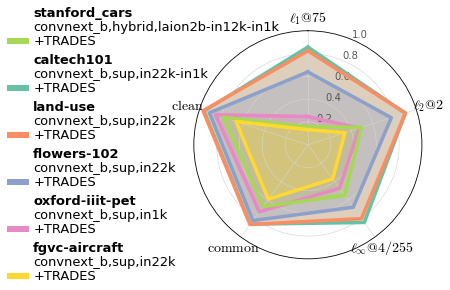

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from process_database import process_grouped_df, process_rankings

# Use Computer Modern for math (matches LaTeX papers) but sans-serif for body text.
# This gives clean, modern legend text with proper LaTeX-style math labels.
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['font.family']      = 'sans-serif'
mpl.rcParams['font.sans-serif']  = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['font.size']        = 10

# ─────────────────────────────────────────────────────────────────────────────
# Same data prep as your original script
# ─────────────────────────────────────────────────────────────────────────────
xtick_label_map = {
    "hybrid": "Hybrid", "fusion": "Fusion",
    "self-supervised": "Uni-SS", "self-supervised (multimodal)": "Multi-SS",
    "supervised": "Sup.", "supervised (robust)": "Robust",
    "supervised (multistep)": "Multistep",
    "fully attention": "attention", "fully convolutional": "convolution",
    "CLASSIC_AT": "Classic AT", "TRADES_v2": "TRADES",
    'fgvc-aircraft-2013b': 'fgvc-aircraft',
    'uc-merced-land-use-dataset': 'land-use',
}

datas = ['stanford_cars', 'oxford-iiit-pet', 'caltech101',
         'flowers-102', 'fgvc-aircraft-2013b', 'uc-merced-land-use-dataset']

results = []
grouped_df = process_rankings(process_grouped_df(final_data))

for dataset in sorted(datas):
    sub = grouped_df[(dataset,)].reset_index()
    sub["rank1"] = sub['borda'].rank(ascending=False, method='min')
    sub["rank2"] = sub['geom'].rank(ascending=False, method='min')
    sub = sub[sub['rank1'] == 1]
    if sub.shape[0] > 1:
        sub = sub[sub['rank2'] == 1]
    metric_dict = {m: float(sub[m]) for m in
                   ['L1_acc', 'L2_acc', 'Linf_acc', 'clean_acc', 'common_acc']}
    metric_dict['backbone_name'] = sub.get("backbone_name").iloc[0]
    metric_dict['loss_function'] = sub.get("loss_function").iloc[0]
    metric_dict['dataset']       = dataset
    results.append(metric_dict)

results = pd.DataFrame(results)

categories = ['L1_acc', 'L2_acc', 'Linf_acc', 'common_acc', 'clean_acc']
symbol_labels = [
    r"$\ell_1@75$",
    r"$\ell_2@2$",
    r"$\ell_\infty@4/255$",
    r"$\mathrm{common}$",
    r"$\mathrm{clean}$",
]

# Sort by polygon area (draw smallest on top)
results['area'] = results[categories].sum(axis=1)
results_sorted = results.sort_values(by='area', ascending=False).reset_index(drop=True)

# Identify the longest legend label so we can put it first in the legend
results_sorted['_legend_len'] = (
    results_sorted['dataset'].astype(str).str.len()
    + results_sorted['backbone_name'].astype(str).str.len()
    + results_sorted['loss_function'].astype(str).str.len()
)
longest_idx = results_sorted['_legend_len'].idxmax()

# ─────────────────────────────────────────────────────────────────────────────
# Build the figure
# Two subplots: empty axis on the left for the legend, polar axis on the right
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(6.0, 3.3))   # inches; 6.0 × 3.3 ≈ 432 × 238 px @ 72dpi
                                        # adjust to match your column width

gs = fig.add_gridspec(1, 2, width_ratios=[0.45, 0.55],
                      left=0.02, right=0.98, top=0.98, bottom=0.02,
                      wspace=0.0)
ax_legend = fig.add_subplot(gs[0, 0]); ax_legend.axis('off')
ax        = fig.add_subplot(gs[0, 1], projection='polar')

# Angles for 5 evenly-spaced axes, starting at the top, going clockwise
n_axes = len(categories)
angles = np.linspace(0, 2*np.pi, n_axes, endpoint=False)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)              # clockwise

# Use Set2 colors (same palette as your original)
import matplotlib.cm as cm
colors = plt.get_cmap('Set2').colors

# Build legend handles separately so we can control their order
legend_handles = []
legend_labels  = []

for i, (_, row) in enumerate(results_sorted.iterrows()):
    values = [row[c] for c in categories]
    values_closed = values + [values[0]]
    angles_closed = np.concatenate([angles, [angles[0]]])

    color = colors[i % len(colors)]

    line, = ax.plot(angles_closed, values_closed, color=color, linewidth=3.5)
    ax.fill(angles_closed, values_closed, color=color, alpha=0.30)

    dataset_label  = xtick_label_map.get(row['dataset'],       row['dataset'])
    backbone_label = xtick_label_map.get(row['backbone_name'], row['backbone_name'])
    loss_label     = xtick_label_map.get(row['loss_function'], row['loss_function'])

    # Plain text — no mathtext — so underscores and hyphens render literally.
    # Bolding of the dataset name is handled below via a custom legend renderer.
    legend_text = f"{dataset_label}\n{backbone_label}\n+{loss_label}"
    legend_handles.append(line)
    legend_labels.append((legend_text, row.name))

# Reorder legend so the longest entry is first
def order_key(item):
    _, original_idx = item[1] if isinstance(item, tuple) else (None, None)
    return 0 if original_idx == longest_idx else 1

ordered = sorted(zip(legend_handles, legend_labels),
                 key=lambda hl: 0 if hl[1][1] == longest_idx else 1)
handles_ordered = [h for h, _ in ordered]
labels_ordered  = [lbl for _, (lbl, _) in ordered]

# Axis labels (the math labels around the polygon)
ax.set_xticks(angles)
ax.set_xticklabels(symbol_labels, fontsize=14)

# Radial gridlines and tick labels
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10, color='#555')
ax.tick_params(axis='x', pad=2)         # PULL ANGULAR LABELS CLOSE TO POLYGON
ax.grid(color='lightgray', linewidth=0.6)

# Place the legend in the left subplot.
# We bypass matplotlib's default Text-per-entry rendering and use a custom
# legend handler that lets us style each line of a multi-line label
# differently. Specifically: dataset name in BOLD, config + loss in regular.
from matplotlib.legend_handler import HandlerBase
from matplotlib.offsetbox import TextArea, VPacker, HPacker, DrawingArea
from matplotlib.lines import Line2D


class StyledMultilineHandler(HandlerBase):
    """Legend handler: colored line swatch + multi-line label with bold first line."""
    def __init__(self, color, lines, **kwargs):
        super().__init__(**kwargs)
        self._color = color
        self._lines = lines  # list of (text, fontdict) tuples

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        # Build a single horizontal line swatch
        swatch = Line2D([0, width * 0.6], [height / 2, height / 2],
                        color=self._color, linewidth=2.5,
                        transform=trans)
        return [swatch]


# Simpler approach: build the legend manually with offset boxes for full control.
# This gives us colored swatches on the left and styled multi-line text on the right.
from matplotlib.offsetbox import (AnchoredOffsetbox, TextArea, VPacker,
                                  HPacker, DrawingArea)
from matplotlib.patches import Rectangle

ax_legend.clear()
ax_legend.axis('off')

entry_boxes = []
for handle, (text, original_idx) in ordered:
    color = handle.get_color()
    lines = text.split('\n')

    # Color swatch (small horizontal line)
    swatch = DrawingArea(22, 14, 0, 0)
    swatch.add_artist(Rectangle((0, 4), 22, 6, facecolor=color, edgecolor='none'))

    # Stack of three text lines: bold dataset, regular config, regular loss
    text_lines = []
    for j, line in enumerate(lines):
        weight = 'bold' if j == 0 else 'normal'
        text_lines.append(TextArea(line, textprops=dict(fontsize=13, weight=weight)))
    text_block = VPacker(children=text_lines, align='left', pad=0, sep=1)

    # Combine swatch + text horizontally
    entry = HPacker(children=[swatch, text_block], align='top', pad=0, sep=4)
    entry_boxes.append(entry)

# Stack all entries vertically with breathing room
legend_box = VPacker(children=entry_boxes, align='left', pad=0, sep=6)

anchored = AnchoredOffsetbox(
    loc='center left', child=legend_box,
    pad=0.0, borderpad=0.0,
    frameon=False,
    bbox_to_anchor=(0.0, 0.5),
    bbox_transform=ax_legend.transAxes,
)
ax_legend.add_artist(anchored)

# Save
out = "./paper_figures/best_performing_per_dataset.pdf"
fig.savefig(out, bbox_inches='tight', pad_inches=0.05)
print(f"Saved: {out}")
plt.show()